# 410 — Zone discovery (blob overlays → manual windows)

The first, **exploratory** step of the confirmatory pooling pipeline. It loads the **same
canonical samples the clustering pipeline uses** (one sample = the trial-averaged ERSP per
electrode × condition, shape 129 × 300), overlays every contact's segmented blobs so you can
*see* where activity concentrates in time, and ends with a cell where **you hand-define** the
pooling windows.

**The warped time axis.** Each ERSP is time-warped **50% stimulus / 50% response**, so the
vertical dashed line at bin **150 (50%)** marks **response onset**: left of it = sensing /
perception, right of it = response / production.

**What to look for.** Each blob is drawn as a **red (positive) / blue (negative) ellipse
outline**, its shade scaled by the blob's mean dB. Stacked across all contacts, dense bands of
outlines reveal the time regions where the dataset reliably responds — the candidate **pooling
zones**. The time-marginal plot underneath quantifies the same thing (contacts active per bin).

**Two resolutions (`USE_DS`).** Default `USE_DS=True` explores the fast **15×30 band-downsampled**
grid via per-condition mean band×time heatmaps; `USE_DS=False` runs the full-res **129×300** blob
overlays, thinned by a tunable **`SCORE_PCT`** blob-score gate so they stay readable. See §1.

**The goal:** read these, then in the final cell type the boxcar + Gaussian windows for the
three zones — **perception**, **pre_articulation**, **audio** — saved to
`outputs/pooling/window_config.json` for `420` to pool over.


In [37]:
import os, sys
from pathlib import Path
import numpy as np, pandas as pd
from IPython.display import display, Markdown, Image
sys.path.insert(0, str(Path('..').resolve()))
from functions import lf_pool as P

INPUT_DIR = Path(r'\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY')
if not INPUT_DIR.exists():
    INPUT_DIR = Path('../01_FBM_Analysis/outputs/04_ersp_LM_RAWONLY').resolve()

print('INPUT_DIR :', INPUT_DIR, '| exists:', INPUT_DIR.exists())
print('OUTPUTS   :', P.OUTPUTS_ROOT)
print('COORDS    :', P.COORDS_DIR, '| exists:', P.COORDS_DIR.exists())
print('conditions:', P.CONDITIONS, '| zones:', P.DEFAULT_ZONES)
print('feature sets:', P.FEATURE_SETS, '| window shapes:', P.WINDOW_SHAPES)


INPUT_DIR : \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY | exists: True
OUTPUTS   : \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling
COORDS    : \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\250_recon\fsaverage\coords | exists: True
conditions: ('audio', 'picture', 'reading') | zones: ('perception', 'pre_articulation', 'audio')
feature sets: ('hg', 'bands15') | window shapes: ('boxcar', 'gaussian')


## 1 — Load the canonical dataset (+ choose resolution)
Ungated: every electrode × condition ERSP for patients with all three conditions (windowed
gating happens in `420`). The heavy walk is cached.

**Resolution toggle.** `USE_DS=True` works on the fast **15×30 band-downsampled** grid (the
clustering "rawds" rep — good for preliminary iteration); set it `False` for the full-res
**129×300** ERSPs (the real run). The blob overlays only make sense at full res, so in ds mode
they're replaced by per-condition mean band×time **heatmaps** (§2) and a power time-marginal (§3).

**Score gate (full-res only).** When `USE_DS=False`, `SCORE_PCT` drops the weakest blobs from the
overlays so they aren't an unreadable mess — slide it up to show only stronger blobs.


In [35]:
# ---- knobs ----
USE_DS       = False     # True: fast 15x30 band-downsampled grid · False: full-res 129x300
SCORE_PCT    = 33.0     # full-res overlays only: drop blobs below this score percentile
DS_TIME_BINS = 30

df_meta, X_full = P.prepare_pooling_dataset(INPUT_DIR)
X = P.downsample_dataset(X_full, time_bins=DS_TIME_BINS) if USE_DS else X_full
score_min = None if USE_DS else P.resolve_score_gate(X_full, pct=SCORE_PCT)
print('samples:', len(df_meta), '| grid:', 'ds' if USE_DS else 'full', '| X:', X.shape)
df_meta.head()


[lf_dataset cache hit] \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\_dataset\pooling\_raw_ungated
  8872 samples · X_3d.shape=(8872, 129, 300)
[lf_pool] 8872 samples, 8872 with a contact key, X_3d=(8872, 129, 300)



KeyboardInterrupt



In [ ]:
print(P.__file__)
print(hasattr(P, 'downsample_dataset'))   # -> True

## 2 — Activity per condition
**ds mode** (`USE_DS=True`): per-condition **mean band×time heatmap** — bright patches = where
the dataset reliably responds. **full-res mode**: blob **overlays**, red = positive / blue =
negative, outline shade ∝ |mean dB|, thinned by the `SCORE_PCT` gate. Dense bands → candidate
pooling zones. (⚠️ overlay ellipses are moment-matched approximations of each blob's extent.)


In [ ]:
disc = P.new_run_dir('discovery')
print('discovery run:', disc)
for cond in P.CONDITIONS:
    if USE_DS:
        png = P.plot_ds_heatmap(X, df_meta, cond, disc / f'ds_heatmap_{cond}.png')
    else:
        png = P.plot_blob_overlay(X_full, df_meta, cond, disc / f'overlay_{cond}.png',
                                  score_min=score_min)
    display(Image(filename=str(png)))


discovery run: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling\discovery\runs\20260611_141203


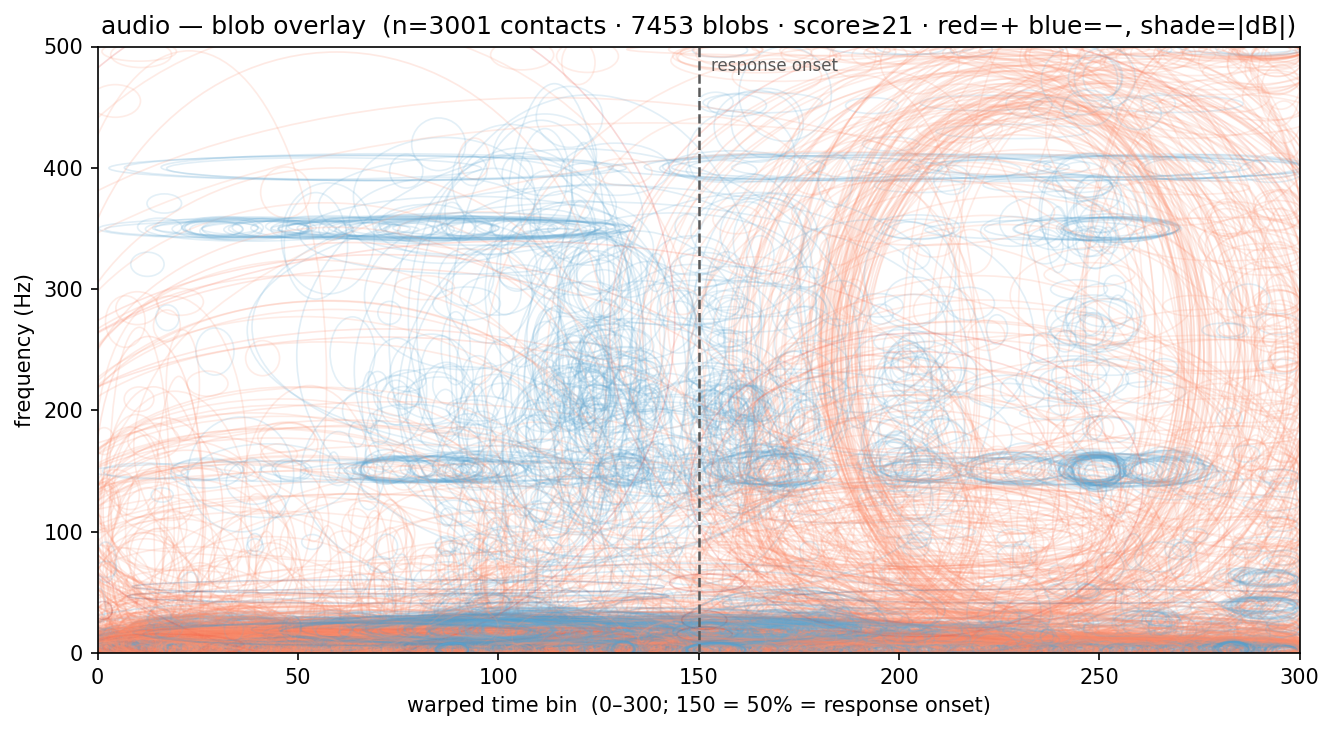

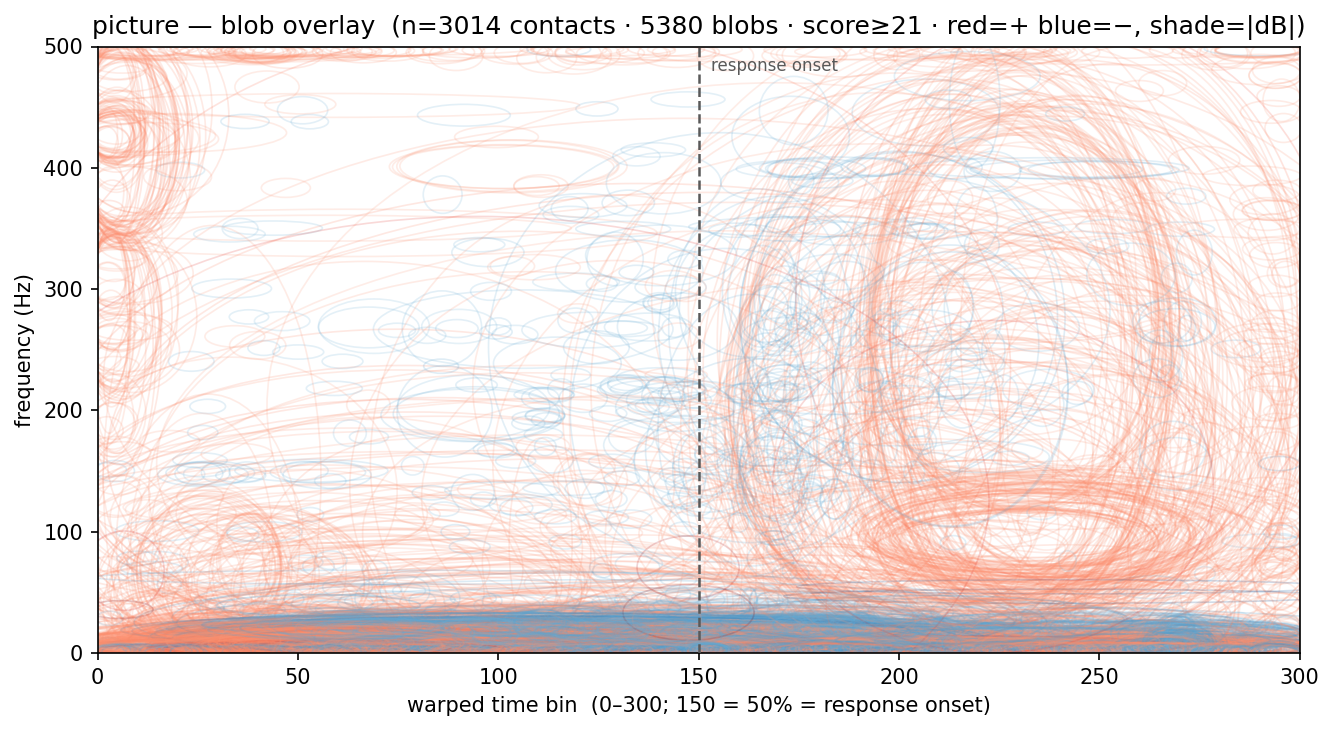

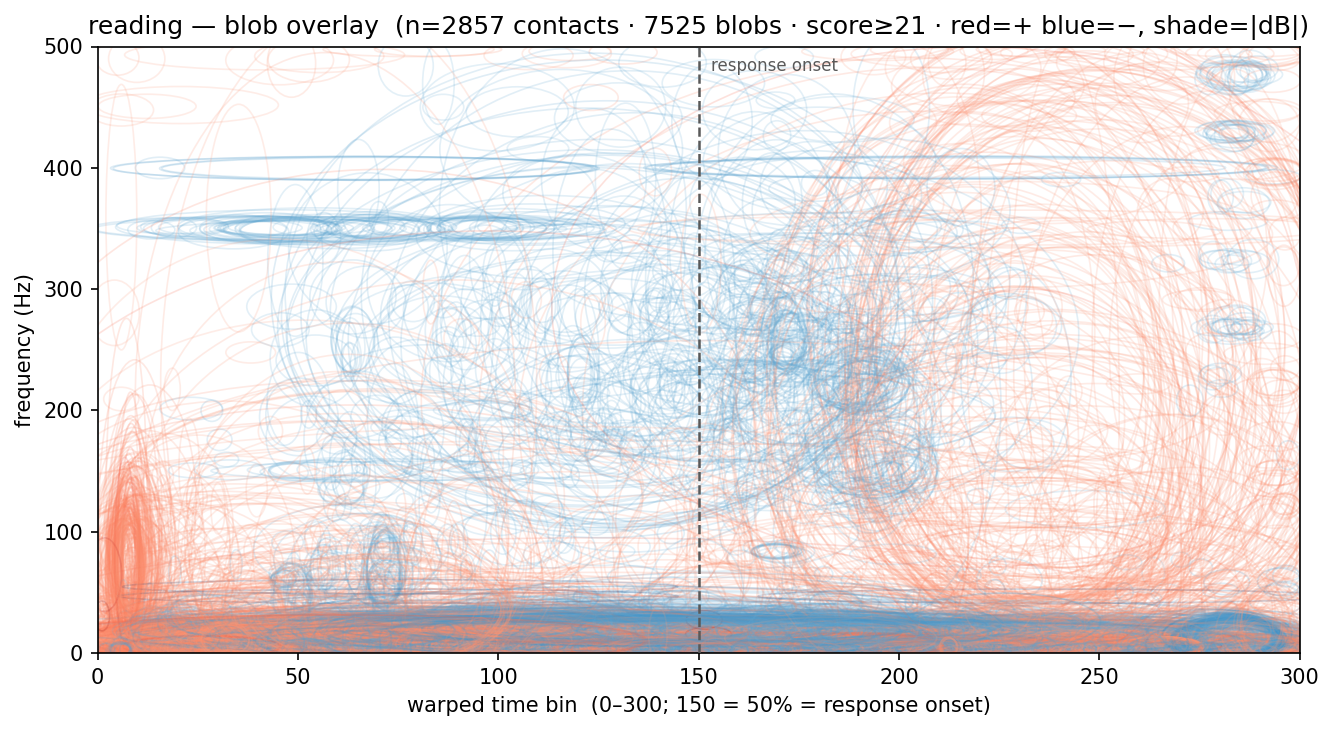

In [31]:
disc = P.new_run_dir('discovery')
print('discovery run:', disc)
for cond in P.CONDITIONS:
    png = P.plot_blob_overlay(X_full, df_meta, cond, disc / f'overlay_{cond}.png',
                                  score_min=score_min)
    display(Image(filename=str(png)))


## 3 — Time-marginal
The quantitative read-off for choosing windows. **ds mode**: mean positive / negative band power
across contacts × bands at each time. **full-res**: count of contacts with a positive/negative
blob active at each bin. Peaks/plateaus = the windows worth pooling.


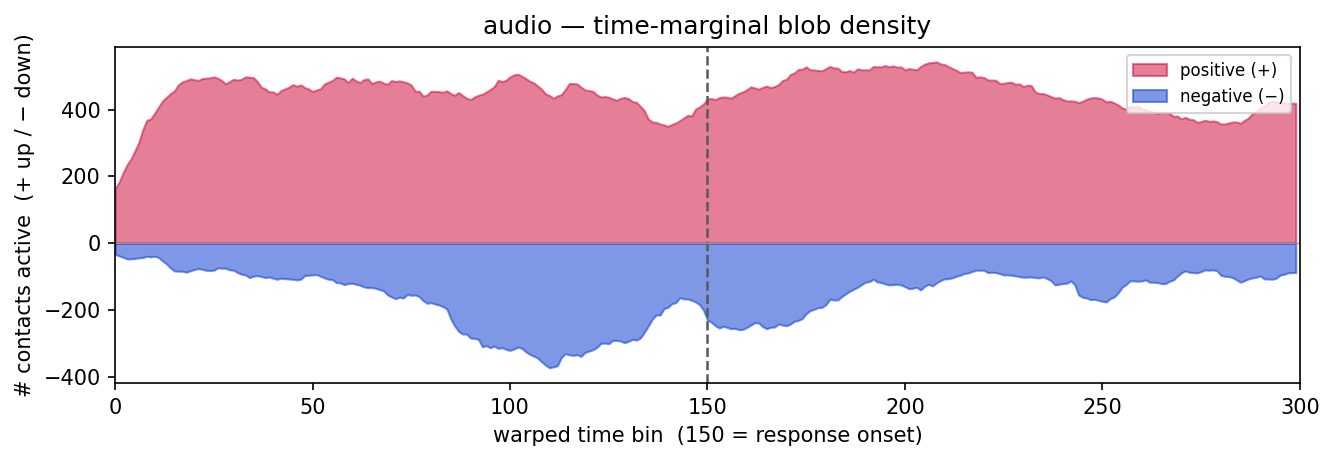

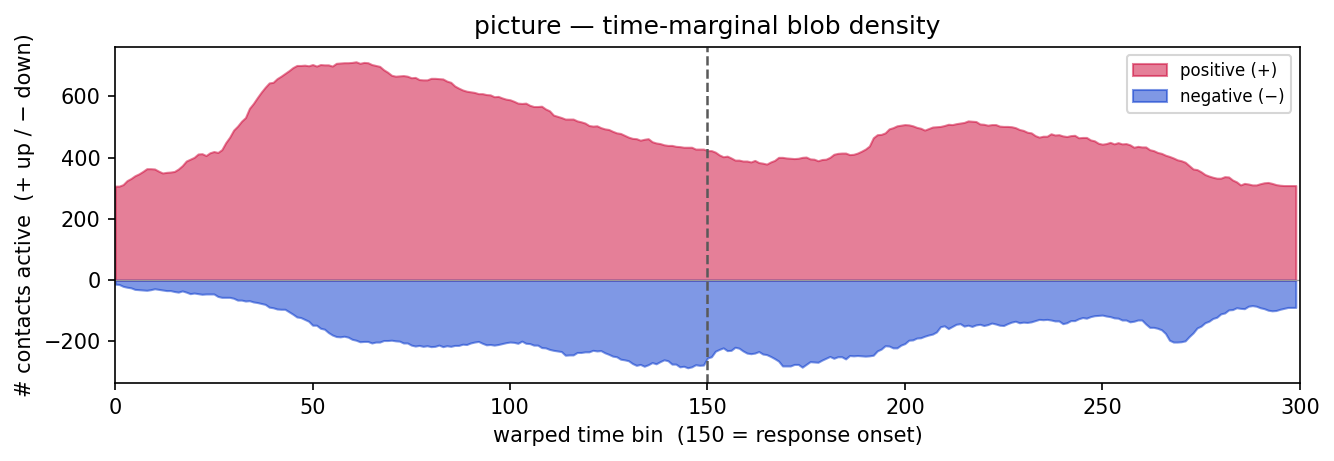

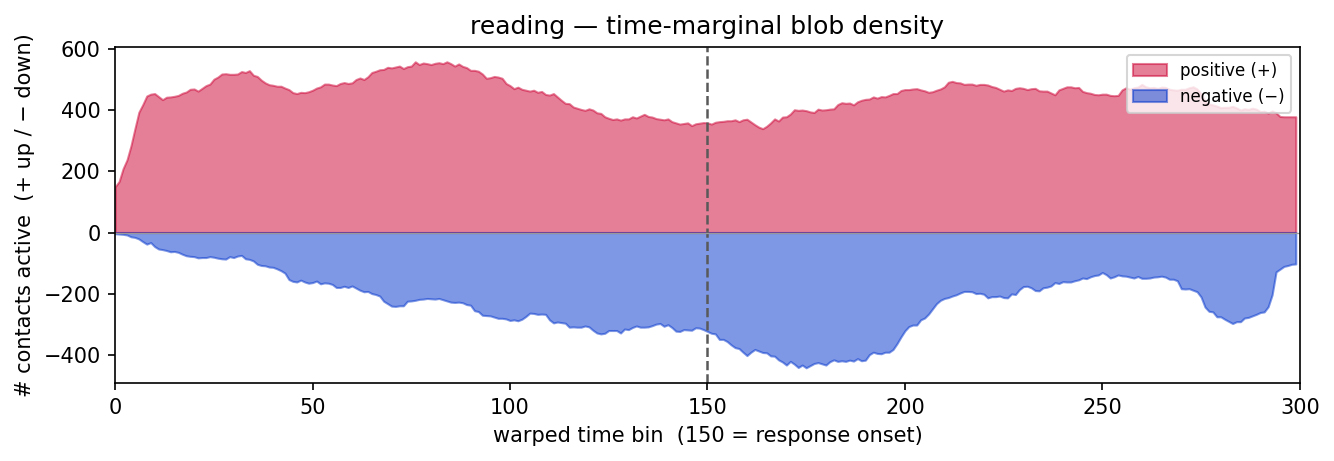

In [32]:
for cond in P.CONDITIONS:
    if USE_DS:
        png = P.plot_ds_time_marginal(X, df_meta, cond, disc / f'ds_time_marginal_{cond}.png')
    else:
        png = P.plot_time_marginal(X_full, df_meta, cond, disc / f'time_marginal_{cond}.png',
                                   score_min=score_min)
    display(Image(filename=str(png)))


## 4 — Define the pooling windows  ✍️  (edit this cell)
Fill in the three zones from what you saw above. **All numbers are percentages of the 0–300
warped axis** (50% = response onset). Each zone needs **both** a `boxcar` (the primary, equal-
weight window — `t_lo_pct`/`t_hi_pct`) **and** a `gaussian` (the robustness window —
`center_pct`/`sigma_pct`). The seed values below are placeholders; overwrite them.

> The pooling is *permissive by design*: each zone targets activity that is **definitely
> present** in its window — it does not try to be exclusive about activity elsewhere.


saved -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling\window_config.json


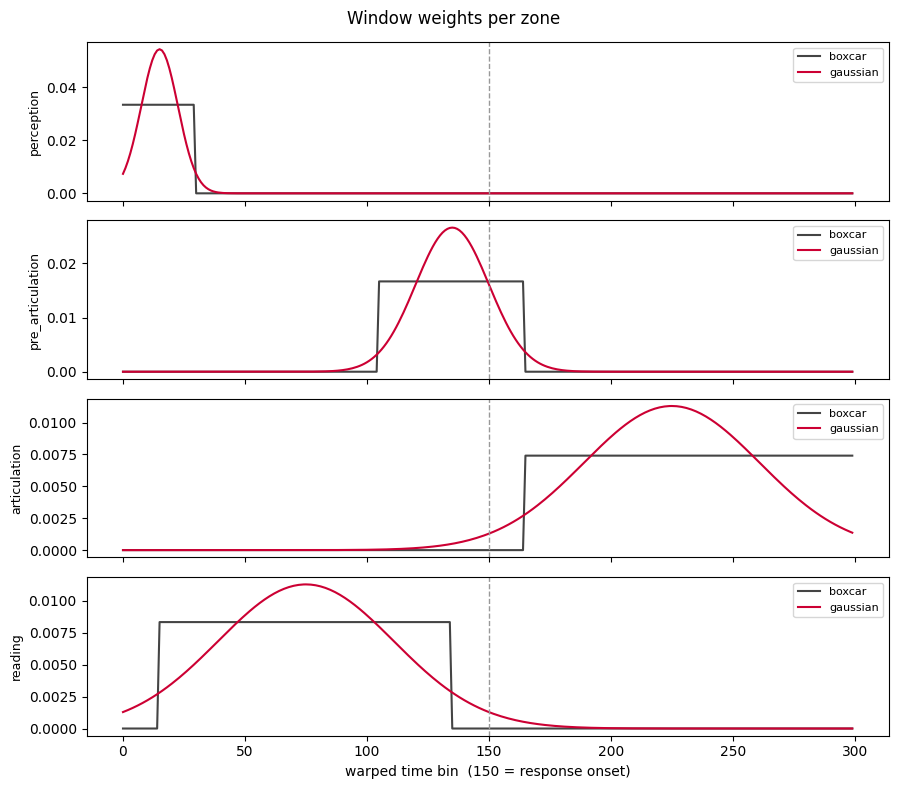

In [33]:
cfg = {
    "schema_version": 1,
    "n_time": P.N_TIME,
    "stim_frac": P.STIM_FRAC,           # 50% mark = response onset = bin 150
    "axis_units": "percent_of_300_warped_axis",
    "zones": {
        # zone               boxcar (equal weight)         gaussian (centre-weighted)
        # "perception":       {"boxcar": {"t_lo_pct": 0,  "t_hi_pct": 50},
        #                      "gaussian": {"center_pct": 25, "sigma_pct": 10}},
        # "pre_articulation": {"boxcar": {"t_lo_pct": 40, "t_hi_pct": 60},
        #                      "gaussian": {"center_pct": 50, "sigma_pct": 8}},
        # "audio":            {"boxcar": {"t_lo_pct": 50, "t_hi_pct": 100},
        #                      "gaussian": {"center_pct": 75, "sigma_pct": 12}},
        "perception":       {"boxcar": {"t_lo_pct": 0,  "t_hi_pct": 10},
                             "gaussian": {"center_pct": 5, "sigma_pct": 2.5}},
        "pre_articulation": {"boxcar": {"t_lo_pct": 35, "t_hi_pct": 55},
                             "gaussian": {"center_pct": 45, "sigma_pct": 5}},
        "articulation":            {"boxcar": {"t_lo_pct": 55, "t_hi_pct": 100},
                             "gaussian": {"center_pct": 75, "sigma_pct": 12}},
        "reading":            {"boxcar": {"t_lo_pct": 5, "t_hi_pct": 45},
                             "gaussian": {"center_pct": 25, "sigma_pct": 12}},
    },
}
P.validate_window_config(cfg)
cfgp = P.save_window_config(cfg, P.OUTPUTS_ROOT / 'window_config.json')
print('saved ->', cfgp)
P.plot_window_preview(cfg);
